In [ ]:
from google.colab import files
upload = files.upload()

Saving Copy of dose_vbm (for Alex) - complete_test_data.csv to Copy of dose_vbm (for Alex) - complete_test_data.csv


In [43]:
import pandas as pd
import numpy as np
import re
import torch
from torch.utils.data import TensorDataset, DataLoader, random_split, Subset, Dataset
import torch.nn as nn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, accuracy_score, top_k_accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

In [ ]:
raw_df = pd.read_csv(r"/content/Copy of dose_vbm (for Alex) - complete_test_data.csv", sep=None, engine="python")
df = raw_df.copy()
df.head(10)

,Unnamed: 0,dose_vbm_org,Primary Class,Seconary Class,Thirtiary Class
0,1,0.1X3/DAY SL + 0.1X3/ IN R,TID,TID,TID
1,2,0.4X2 PER DAY,BID,BID,BID
2,3,"#3, 1 TAB Q.I.D. P.R.N.",QID,QID,QID
3,4,"'FULL DOSE' TWICE OR THREE TIMES DAILY, PRN",BID,NaN,NaN
4,5,(0.02 %) TAKE 2. ML VIA NEBULIZATION 4 TIMES A...,NaN,NaN,NaN
5,6,(0.025%) 1 DROP 1 TIME PER DAY AS NEEDED,NaN,NaN,NaN
6,7,"(0.1 %), BID AS NECESSARY",NaN,NaN,NaN
7,8,"(0.25 TO ONE 80 MG TABLET), TID PRN",NaN,NaN,NaN
8,9,(0.5 B.I.D. P.R.N.),NaN,NaN,NaN
9,10,"(0.5 MG, TID(TAKE1/2 TAB THREE TIMES A DAY AS ...",NaN,NaN,NaN


In [ ]:
df.columns
df = df.drop('Unnamed: 0', axis=1)
df.head(10)

,dose_vbm_org,Primary Class,Seconary Class,Thirtiary Class
0,0.1X3/DAY SL + 0.1X3/ IN R,TID,TID,TID
1,0.4X2 PER DAY,BID,BID,BID
2,"#3, 1 TAB Q.I.D. P.R.N.",QID,QID,QID
3,"'FULL DOSE' TWICE OR THREE TIMES DAILY, PRN",BID,NaN,NaN
4,(0.02 %) TAKE 2. ML VIA NEBULIZATION 4 TIMES A...,NaN,NaN,NaN
5,(0.025%) 1 DROP 1 TIME PER DAY AS NEEDED,NaN,NaN,NaN
6,"(0.1 %), BID AS NECESSARY",NaN,NaN,NaN
7,"(0.25 TO ONE 80 MG TABLET), TID PRN",NaN,NaN,NaN
8,(0.5 B.I.D. P.R.N.),NaN,NaN,NaN
9,"(0.5 MG, TID(TAKE1/2 TAB THREE TIMES A DAY AS ...",NaN,NaN,NaN


In [ ]:
# ---------- helpers ----------
_NUM_WORDS = {
    "one":1, "once":1, "single":1,
    "two":2, "twice":2, "double":2,
    "three":3, "thrice":3,
    "four":4
}
_NUM_TO_LABEL = {1:"QD", 2:"BID", 3:"TID", 4:"QID"}

def _norm(s: str) -> str:
  if s is None: return ""
  s = str(s).lower()
  s = s.replace("\n", " ").replace("\\n", " ")
  s = re.sub(r"[()\[\],;:+\-]", " ", s)   # keep digits/letters; drop clutter
  s = s.replace(".", "")                    # "p.r.n." -> "prn"
  s = re.sub(r"\s+", " ", s).strip()
  return s

def _token_to_int(tok: str) -> int | None:
  tok = tok.lower()
  if tok.isdigit():
      n = int(tok)
      return n if n in (1,2,3,4) else None
  return _NUM_WORDS.get(tok)

def _find_direct(s: str):
  pats = [
      # --- ADDED: Specific override for "2 qhs" to be interpreted as BID ---
      (r"\b2\s*qhs\b", "BID"),

      (r"\bqid\b|\bq\s*i\s*d\b", "QID"),
      (r"\btid\b|\bt\s*i\s*d\b", "TID"),
      (r"\bbid\b|\bb\s*i\s*d\b", "BID"),
      (r"\bqwk\b|\b(once|every)\s+(a|per)?\s*week(ly)?\b|\b1\s*(x|time)\s*(a|per|/)\s*week(ly)?\b", "QWK"),
      (r"\bqd\b|\bq\s*d\b|\bdaily\b|\bonce\s+(a|per)?\s*day\b|\b1\s*(x|time)?\s*(per|/)?\s*(day|daily)\b", "QD"),
      (r"\bq\s*24\s*h\b|\bevery\s*24\s*h(ou)?rs?\b", "QD"),
      # --- MODIFIED: Added "at bedtime" to the list of QD indicators ---
      (r"\bqam\b|\bqpm\b|\bqhs\b|\b(at\s*)?bedtime\b", "QD"),
      (r"\bprn\b|\b(as|when|if)\s+needed\b|\bas\s+(necessary|required)\b", "PRN"),
  ]
  for pat, lab in pats:
      m = re.search(pat, s, flags=re.I)
      if m:
          return lab, m.span(0)
  return None

def _find_every_hours(s: str):
  m = re.search(r"\bq\s*(\d{1,2})\s*h\b|\bevery\s*(\d{1,2})\s*(h|hr|hrs|hour|hours)\b", s, flags=re.I)
  if not m:
      return None
  val = m.group(1) or m.group(2)
  try:
      h = int(val)
      if h:
          per_day = round(24 / h)
          if per_day in _NUM_TO_LABEL:
              return _NUM_TO_LABEL[per_day], m.span(0)
  except ValueError:
      pass
  return None

def _find_numeric_daybased(s: str):
  patterns = [
      r"x\s*(\d)\s*/\s*(day|daily)\b",               # x3/day
      r"x\s*(\d)\s*(?:per\s*)?(day|daily)\b",        # x2 per day
      r"\b(\d)\s*x\s*(?:per\s*)?(day|daily)\b",      # 3x per day
      r"\b(\d)\s*(times?|time)\s*(?:a|per|/)?\s*(day|daily)\b",  # 3 times a day
      r"\b(\d)\s*/\s*(day|daily)\b",                 # 3/day
      r"\b(\d)\s*(?:x|×)\b.*\b(day|daily)\b",        # 3× daily
      r"x\s*(\d)\s*/",                               # x3/  -> assume per day
  ]
  for pat in patterns:
      m = re.search(pat, s, flags=re.I)
      if m:
          n = int(m.group(1))
          if n in _NUM_TO_LABEL:
              return _NUM_TO_LABEL[n], m.span(0)
  return None

def _find_worded_counts_or_range(s: str):
  rng = re.search(
      r"\b(one|once|single|two|twice|double|three|thrice|four|1|2|3|4)\b"
      r".{0,20}?\b(or|to|/|-)\b.{0,20}?\b(one|once|single|two|twice|double|three|thrice|four|1|2|3|4)\b"
      r".{0,20}?\b(day|daily|times?)\b",
      s, flags=re.I
  )
  if rng:
      a = _token_to_int(rng.group(1))
      b = _token_to_int(rng.group(3))
      if a in _NUM_TO_LABEL and b in _NUM_TO_LABEL:
          return _NUM_TO_LABEL[min(a,b)], rng.span(1)


  m = re.search(
      r"\b(once|one|single|twice|two|double|three|thrice|four)\b"
      r".{0,20}?\b(day|daily|times?)\b",
      s, flags=re.I
  )
  if m:
      n = _token_to_int(m.group(1))
      if n in _NUM_TO_LABEL:
          return _NUM_TO_LABEL[n], m.span(0)
  return None

def _detect_once(s: str):
  for finder in (_find_worded_counts_or_range, _find_numeric_daybased, _find_every_hours, _find_direct):
      res = finder(s)
      if res:
          return res
  return None

# ---------- main API ----------
def classify_all(text: str, max_labels: int = 3):
  """
  Return up to `max_labels` frequency labels (primary -> secondary -> tertiary)
  by repeatedly finding one label, removing the matched chunk, and continuing.
  """
  s = _norm(text)
  out = []
  for _ in range(max_labels):
      found = _detect_once(s)
      if not found:
          break
      label, span = found
      out.append(label)
      s = (s[:span[0]] + " " + s[span[1]:]).strip()
      s = re.sub(r"\s+", " ", s)

  if len(out) > 0:
    return out
  else:
    return [None, None, None]

In [ ]:
def test_algo(n: int):
    data = {"doses": [], "Primary class": [], "Secondary class": [], "Tertiary class": []}
    for i in range(n):
        dose_value = df.loc[i, 'dose_vbm_org']
        classifications = classify_all(dose_value)

        data["doses"].append(dose_value)

        primary = classifications[0] if len(classifications) > 0 else None
        secondary = classifications[1] if len(classifications) > 1 else None
        tertiary = classifications[2] if len(classifications) > 2 else None

        data["Primary class"].append(primary)
        data["Secondary class"].append(secondary)
        data["Tertiary class"].append(tertiary)

    test_res = pd.DataFrame.from_dict(data)
    return test_res

def create_multitask_target_tensor(df_in):
  df = df_in.copy()

  # 1. Create a global vocabulary
  all_labels = set(df['Primary class'].unique()) | \
               set(df['Secondary class'].unique()) | \
               set(df['Tertiary class'].unique())

  all_labels.discard(None)
  all_labels.discard(np.nan)

  # Reserve 0 for 'None' and map all other labels to integers 1, 2, 3...
  label_to_int = {label: i + 1 for i, label in enumerate(sorted(list(all_labels)))}
  label_to_int['None'] = 0

  # 2. Map strings to integers for each column
  primary_encoded = df['Primary class'].fillna('None').map(label_to_int)
  secondary_encoded = df['Secondary class'].fillna('None').map(label_to_int)
  tertiary_encoded = df['Tertiary class'].fillna('None').map(label_to_int)

  # 3. Zip into tuples and add as a new column to the DataFrame
  df['target_tuple'] = list(zip(primary_encoded, secondary_encoded, tertiary_encoded))

  return df, label_to_int

training_df = test_algo(65500)
encoded_df, vocab = create_multitask_target_tensor(training_df)
encoded_df

,doses,Primary class,Secondary class,Tertiary class,target_tuple
0,0.1X3/DAY SL + 0.1X3/ IN R,TID,TID,None,"(6, 6, 0)"
1,0.4X2 PER DAY,BID,None,None,"(1, 0, 0)"
2,"#3, 1 TAB Q.I.D. P.R.N.",QID,PRN,None,"(4, 2, 0)"
3,"'FULL DOSE' TWICE OR THREE TIMES DAILY, PRN",BID,TID,QD,"(1, 6, 3)"
4,(0.02 %) TAKE 2. ML VIA NEBULIZATION 4 TIMES A...,QID,PRN,None,"(4, 2, 0)"
...,...,...,...,...,...
65495,"1 CI, QD",QD,None,None,"(3, 0, 0)"
65496,"1 CM, QD",QD,None,None,"(3, 0, 0)"
65497,"1 CO, QD",QD,None,None,"(3, 0, 0)"
65498,"1 COURSE DURING FIRST TRIMESTER 300 MILLIGRAM, QD",QD,None,None,"(3, 0, 0)"


In [ ]:
def tuple_to_id(t): return int(t[0])*49 + int(t[1])*7 + int(t[2])
def id_to_tuple(i): return (i//49, (i%49)//7, i%7)

# Data columns
texts = encoded_df["doses"].astype(str).to_numpy()
labels = np.array([tuple_to_id(t) for t in encoded_df["target_tuple"]], dtype=np.int64)

num_classes = 343
counts = np.bincount(labels, minlength=num_classes)
keep_mask = counts[labels] >= 2

texts = texts[keep_mask]
labels = labels[keep_mask]

# split (80/20)
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(sss.split(texts, labels))

texts_train, texts_val = texts[train_idx], texts[val_idx]
y_train, y_val = labels[train_idx], labels[val_idx]

#  Vectorize text (char TF-IDF works great for symbolic strings)
vec = TfidfVectorizer(analyzer="char", ngram_range=(1,4), max_features=5000, min_df=2)
X_train = vec.fit_transform(texts_train).toarray().astype("float32")
X_val   = vec.transform(texts_val).toarray().astype("float32")

# Hand to tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t   = torch.tensor(X_val,   dtype=torch.float32)
y_val_t   = torch.tensor(y_val,   dtype=torch.long)

# dataset/dataloader
class TextDataset(Dataset):
    def __init__(self, X_t, y_t):
        self.X_t = X_t
        self.y_t = y_t
    def __len__(self):
        return self.X_t.size(0)
    def __getitem__(self, i):
        return self.X_t[i], self.y_t[i]

train_ds = TextDataset(X_train_t, y_train_t)
val_ds   = TextDataset(X_val_t,   y_val_t)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True, drop_last=False)
val_loader   = DataLoader(val_ds,   batch_size=256, shuffle=False, drop_last=False)

# Actual model
class FlatClassifier(nn.Module):
    def __init__(self, in_dim, num_classes=343):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 512), nn.ReLU(),
            nn.Linear(512, 128), nn.ReLU(),
            nn.Linear(128, num_classes)
        )
    def forward(self, x): return self.net(x)

In [29]:
def train_with_live_plot(model, train_loader, val_loader, device, epochs=10, lr=1e-3):
    import numpy as np, torch, torch.nn as nn, matplotlib.pyplot as plt
    from IPython.display import clear_output, display

    crit = nn.CrossEntropyLoss()
    opt  = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses, val_losses, train_accs, val_accs = [], [], [], []

    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    (line1,) = ax[0].plot([], [], label="Train Loss")
    (line2,) = ax[0].plot([], [], label="Val Loss")
    (line3,) = ax[1].plot([], [], label="Train Acc")
    (line4,) = ax[1].plot([], [], label="Val Acc")
    for a, title, ylab in zip(ax, ["Loss", "Accuracy"], ["Loss", "Accuracy"]):
        a.set_title(title)
        a.set_xlabel("Epoch")
        a.set_ylabel(ylab)
        a.legend()

    for epoch in range(1, epochs + 1):
        # ---------- TRAIN ----------
        model.train()
        tr_loss = tr_acc = n = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            logits = model(xb)
            loss = crit(logits, yb)
            loss.backward()
            opt.step()
            tr_loss += loss.item() * xb.size(0)
            tr_acc  += (logits.argmax(1) == yb).sum().item()
            n += xb.size(0)
        tr_loss /= n
        tr_acc  /= n

        # ---------- VALIDATION ----------
        model.eval()
        val_loss = val_acc = m = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                loss = crit(logits, yb)
                val_loss += loss.item() * xb.size(0)
                val_acc  += (logits.argmax(1) == yb).sum().item()
                m += xb.size(0)
        val_loss /= m
        val_acc  /= m

        # ---------- RECORD ----------
        train_losses.append(tr_loss);  val_losses.append(val_loss)
        train_accs.append(tr_acc);     val_accs.append(val_acc)

        # ---------- UPDATE INLINE ----------
        xs = np.arange(1, epoch + 1)
        line1.set_data(xs, train_losses)
        line2.set_data(xs, val_losses)
        line3.set_data(xs, train_accs)
        line4.set_data(xs, val_accs)
        for a in ax:
            a.relim(); a.autoscale_view()
        fig.tight_layout()

        clear_output(wait=True)
        display(fig)
        print(f"Epoch {epoch:02d} | train {tr_loss:.4f} acc {tr_acc:.3f} "
              f"| val {val_loss:.4f} acc {val_acc:.3f}")

    plt.close(fig)
    return {
        "train_losses": train_losses, "val_losses": val_losses,
        "train_accs": train_accs, "val_accs": val_accs
    }

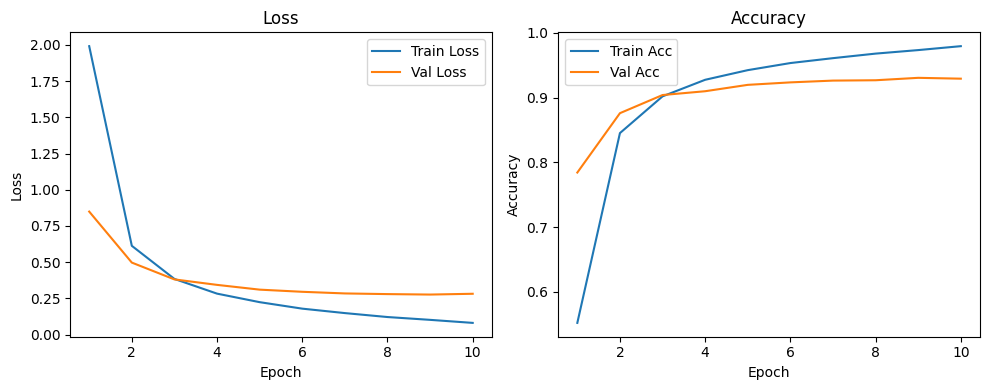

Epoch 10 | train 0.0803 acc 0.980 | val 0.2814 acc 0.929


In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FlatClassifier(X_train.shape[1]).to(device)
history = train_with_live_plot(model, train_loader, val_loader, device, epochs=10, lr=1e-3)



In [40]:
def evaluate(model, val_loader, device):
    model.eval()
    crit = torch.nn.CrossEntropyLoss(reduction="sum")
    all_logits, all_y = [], []
    total_loss, n = 0.0, 0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = crit(logits, yb)
            total_loss += loss.item()
            n += xb.size(0)
            all_logits.append(logits.cpu())
            all_y.append(yb.cpu())

    logits = torch.cat(all_logits, 0).numpy()
    y_true = torch.cat(all_y, 0).numpy()
    y_pred = logits.argmax(1)

    val_loss = total_loss / n
    acc = accuracy_score(y_true, y_pred)
    top3 = top_k_accuracy_score(y_true, logits, k=3, labels=np.arange(logits.shape[1]))
    top5 = top_k_accuracy_score(y_true, logits, k=5, labels=np.arange(logits.shape[1]))

    # ---- Metric summary (1 row) ----
    metrics_df = pd.DataFrame([{
        "Loss": val_loss,
        "Accuracy": acc,
        "Top-3 Accuracy": top3,
        "Top-5 Accuracy": top5
    }])

    # ---- Classification report ----
    # orient="index" converts dict-like report into clean DataFrame
    class_report = classification_report(y_true, y_pred, zero_division=0, output_dict=True)
    classification_df = pd.DataFrame(class_report).transpose()

    # ---- Display both ----
    print("📊 Overall Validation Metrics:")
    display(metrics_df)
    print("\n📋 Detailed Per-Class Report:")
    display(classification_df)

    return {
        "metrics_df": metrics_df,
        "classification_df": classification_df,
        "y_true": y_true,
        "y_pred": y_pred,
        "logits": logits,
    }

# Example usage
eval_out = evaluate(model, val_loader, device)


📊 Overall Validation Metrics:


,Loss,Accuracy,Top-3 Accuracy,Top-5 Accuracy
0,0.281392,0.929373,0.983584,0.991372



📋 Detailed Per-Class Report:


,precision,recall,f1-score,support
0,0.925170,0.814371,0.866242,334.000000
49,0.634615,0.702128,0.666667,47.000000
56,0.500000,0.333333,0.400000,3.000000
57,0.000000,0.000000,0.000000,4.000000
58,0.859649,0.816667,0.837607,60.000000
...,...,...,...,...
339,0.727273,0.500000,0.592593,16.000000
342,1.000000,0.333333,0.500000,3.000000
accuracy,0.929373,0.929373,0.929373,0.929373
macro avg,0.556959,0.485026,0.503496,13097.000000


In [41]:
def id_to_tuple(i):
    return (i//49, (i%49)//7, i%7)

y_true = eval_out["y_true"]
y_pred = eval_out["y_pred"]

true_tuples = np.array([id_to_tuple(i) for i in y_true])
pred_tuples = np.array([id_to_tuple(i) for i in y_pred])

# Per-position accuracy (how often each digit is correct)
pos_acc = (true_tuples == pred_tuples).mean(axis=0)
print(f"Digit accuracies (a,b,c): {pos_acc[0]:.3f}, {pos_acc[1]:.3f}, {pos_acc[2]:.3f}")

# Hamming distance across the 3 digits (0..3)
hamm = (true_tuples != pred_tuples).sum(axis=1)
for d in range(4):
    print(f"Hamming {d}: {(hamm==d).mean():.3f}")

# Show a few mistakes
err_idx = np.where(y_true != y_pred)[0][:10]
for i in err_idx:
    print(f"idx {i}: true {true_tuples[i]} pred {pred_tuples[i]} (ids {y_true[i]}->{y_pred[i]})")


Digit accuracies (a,b,c): 0.959, 0.953, 0.970
Hamming 0: 0.929
Hamming 1: 0.030
Hamming 2: 0.033
Hamming 3: 0.007
idx 0: true [1 3 0] pred [3 0 0] (ids 70->147)
idx 2: true [0 0 0] pred [2 0 0] (ids 0->98)
idx 4: true [3 2 0] pred [3 3 2] (ids 161->170)
idx 26: true [3 6 2] pred [6 2 0] (ids 191->308)
idx 29: true [3 2 0] pred [3 0 0] (ids 161->147)
idx 36: true [2 0 0] pred [0 0 0] (ids 98->0)
idx 66: true [4 3 3] pred [4 3 0] (ids 220->217)
idx 71: true [3 3 0] pred [3 0 0] (ids 168->147)
idx 72: true [1 3 2] pred [3 1 2] (ids 72->156)
idx 76: true [6 3 2] pred [6 2 0] (ids 317->308)


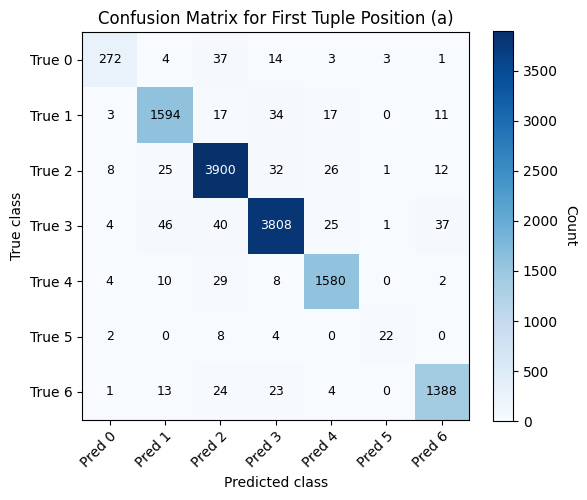

In [44]:
true_a = true_tuples[:, 0]   # first digit of your target tuple
pred_a = pred_tuples[:, 0]

cm_a = confusion_matrix(true_a, pred_a, labels=range(7))

# ---- Plot ----
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm_a, cmap="Blues")

# Add colorbar
cbar = ax.figure.colorbar(im, ax=ax)
cbar.ax.set_ylabel("Count", rotation=-90, va="bottom")

# Set ticks and labels
ax.set(
    xticks=np.arange(7),
    yticks=np.arange(7),
    xticklabels=[f"Pred {i}" for i in range(7)],
    yticklabels=[f"True {i}" for i in range(7)],
    ylabel="True class",
    xlabel="Predicted class",
    title="Confusion Matrix for First Tuple Position (a)"
)

# Rotate x labels for clarity
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Add the counts in each cell
for i in range(cm_a.shape[0]):
    for j in range(cm_a.shape[1]):
        count = cm_a[i, j]
        ax.text(j, i, f"{count}", ha="center", va="center",
                color="white" if count > cm_a.max() / 2 else "black", fontsize=9)

fig.tight_layout()
plt.show()